In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
STYLE_URL = "https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg"
CONTENT_URL = "https://pytorch.org/tutorials/_static/img/neural-style/dancing.jpg"

headers = {"User-Agent": "Mozilla/5.0"}

def download(url, filename):
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req) as response, open(filename, "wb") as out_file:
        out_file.write(response.read())

download(CONTENT_URL, "content.jpg")
download(STYLE_URL, "style.jpg")
print("Downloaded content.jpg and style.jpg")

Downloaded content.jpg and style.jpg


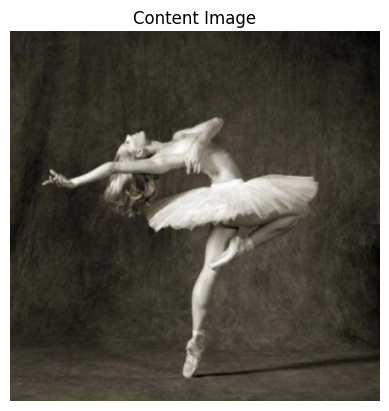

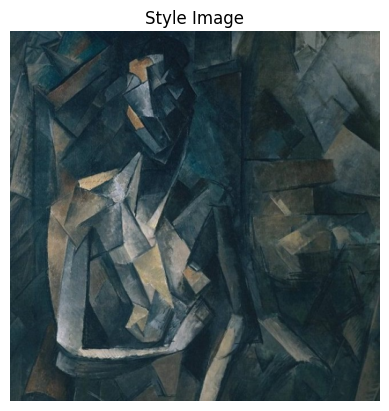

In [ ]:
IMG_SIZE = 512 if torch.cuda.is_available() else 256

loader = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

content_img = load_image("content.jpg")
style_img = load_image("style.jpg")

unloader = transforms.ToPILImage()

def imshow(tensor, title=None):
    image = tensor.cpu().clone().squeeze(0)
    image = unloader(image)
    plt.imshow(image)
    if title: plt.title(title)
    plt.axis("off")
    plt.show()

imshow(content_img, "Content Image")
imshow(style_img, "Style Image")

In [ ]:
class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

def gram_matrix(input):
    b, c, h, w = input.size()
    features = input.view(b * c, h * w)
    G = torch.mm(features, features.t())
    return G.div(b * c * h * w)

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super().__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

In [ ]:
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = mean.view(-1, 1, 1)
        self.std = std.view(-1, 1, 1)

    def forward(self, img):
        return (img - self.mean) / self.std

print("VGG19 loaded.")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 76.3MB/s]


VGG19 loaded.


In [ ]:
content_layers = ["conv_4"]
style_layers = ["conv_1", "conv_2", "conv_3", "conv_4", "conv_5"]

def build_model_and_losses(cnn, mean, std, style_img, content_img):
    normalization = Normalization(mean, std).to(device)
    content_losses = []
    style_losses = []
    model = nn.Sequential(normalization)

    i = 0
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f"conv_{i}"
        elif isinstance(layer, nn.ReLU):
            name = f"relu_{i}"
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f"pool_{i}"
        elif isinstance(layer, nn.BatchNorm2d):
            name = f"bn_{i}"
        else:
            continue

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], (ContentLoss, StyleLoss)):
            break
    model = model[:(i + 1)]

    return model, style_losses, content_losses

model, style_losses, content_losses = build_model_and_losses(
    cnn, cnn_normalization_mean, cnn_normalization_std, style_img, content_img
)

print("Model built with", len(content_losses), "content loss layers and", len(style_losses), "style loss layers.")

Model built with 1 content loss layers and 5 style loss layers.


In [ ]:
NUM_STEPS = 300
STYLE_WEIGHT = 1e6
CONTENT_WEIGHT = 1

input_img = content_img.clone()
input_img.requires_grad_(True)
model.requires_grad_(False)

optimizer = optim.LBFGS([input_img])

print("Running style transfer...")
run = [0]
while run[0] <= NUM_STEPS:

    def closure():
        with torch.no_grad():
            input_img.clamp_(0, 1)

        optimizer.zero_grad()
        model(input_img)

        style_score = sum(sl.loss for sl in style_losses)
        content_score = sum(cl.loss for cl in content_losses)

        style_score *= STYLE_WEIGHT
        content_score *= CONTENT_WEIGHT

        loss = style_score + content_score
        loss.backward()

        run[0] += 1
        if run[0] % 50 == 0:
            print(f"Step {run[0]}: Style Loss: {style_score.item():.4f}, Content Loss: {content_score.item():.4f}")

        return style_score + content_score

    optimizer.step(closure)

with torch.no_grad():
    input_img.clamp_(0, 1)

print("Done!")

Running style transfer...
Step 50: Style Loss: 4.1396, Content Loss: 4.1683
Step 100: Style Loss: 1.1414, Content Loss: 3.0369
Step 150: Style Loss: 0.7058, Content Loss: 2.6488
Step 200: Style Loss: 0.4758, Content Loss: 2.4873
Step 250: Style Loss: 0.3447, Content Loss: 2.4003
Step 300: Style Loss: 0.2634, Content Loss: 2.3485
Done!


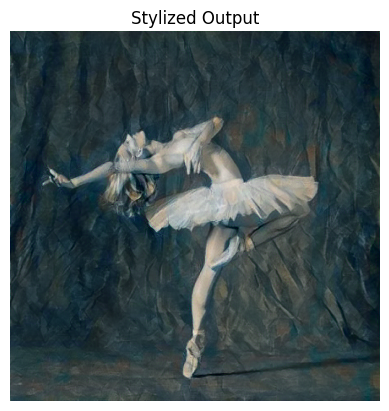

Saved as output.png


In [ ]:
def imshow(tensor, title=None):
    image = tensor.cpu().clone().squeeze(0)
    image = unloader(image)
    plt.imshow(image)
    if title: plt.title(title)
    plt.axis("off")
    plt.show()

imshow(input_img, title="Stylized Output")

output_image = input_img.cpu().clone().squeeze(0)
output_image = unloader(output_image)
output_image.save("output.png")
print("Saved as output.png")